In [ ]:
from google.colab import files
uploaded = files.upload()


Saving final project assigment csv.csv to final project assigment csv.csv


In [ ]:
import pandas as pd

df = pd.read_csv("final project assigment csv.csv")
df.head()


,city,country,country_clean,continent_name,median_salary,average_salary,rent_usd_proxy,utilities_usd_proxy,grocery_item_price_median,salary_pr,rent_pr,grocery_pr,utilities_pr,affordability_score,cluster_label
0,Seoul,South Korea,South Korea,Asia,2593.42,2889.81,1236.810,110.36,3.465,0.483378,0.768972,0.850419,0.784385,34.014295,Low Salary–Low Cost
1,Shanghai,China,China,Asia,3684.93,4027.40,1326.760,88.21,2.055,0.578051,0.800829,0.509310,0.545134,45.969943,Low Salary–Low Cost
2,Guangzhou,China,China,Asia,3684.93,4027.40,610.665,59.65,1.670,0.578051,0.495467,0.412728,0.208663,57.217984,High Cost–Low Salary
3,Mumbai,India,India,Asia,327.97,384.43,611.100,43.57,1.145,0.073095,0.495726,0.162267,0.099251,37.519996,High Cost–Low Salary
4,Delhi,India,India,Asia,327.97,384.43,279.495,49.99,1.025,0.073095,0.234395,0.108144,0.133904,44.962479,High Cost–Low Salary


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt


PATH = PATH = "final project assigment csv.csv"

df = pd.read_csv(PATH)

n_rows, n_cols = df.shape
n_countries = df['country'].nunique()
n_cities = df[['city','country']].drop_duplicates().shape[0]
print(f"Rows: {n_rows:,} | Columns: {n_cols} | Countries: {n_countries} | City-Country pairs: {n_cities:,}")


Rows: 4,956 | Columns: 15 | Countries: 215 | City-Country pairs: 4,956


In [ ]:
dupes = df[df.duplicated(subset=['city','country'], keep=False)].sort_values(['city','country'])
dupes.to_csv("duplicates_city_country.csv", index=False)
print(f"Duplicate rows: {len(dupes):,} (saved to duplicates_city_country.csv)")


Duplicate rows: 0 (saved to duplicates_city_country.csv)


In [ ]:
schema_rows = []
for col in df.columns:
    non_null = df[col].notna().sum()
    miss = len(df) - non_null
    miss_pct = round(100*miss/len(df), 2)
    dtype = str(df[col].dtype)
    row = {"column": col, "dtype": dtype, "non_null": non_null, "missing": miss, "missing_pct": miss_pct}
    if np.issubdtype(df[col].dropna().dtype, np.number):
        row.update({
            "min": float(np.nanmin(df[col])) if non_null>0 else np.nan,
            "p25": float(np.nanpercentile(df[col], 25)) if non_null>0 else np.nan,
            "median": float(np.nanmedian(df[col])) if non_null>0 else np.nan,
            "p75": float(np.nanpercentile(df[col], 75)) if non_null>0 else np.nan,
            "max": float(np.nanmax(df[col])) if non_null>0 else np.nan,
            "mean": float(np.nanmean(df[col])) if non_null>0 else np.nan,
            "std": float(np.nanstd(df[col])) if non_null>0 else np.nan,
        })
    schema_rows.append(row)

schema_df = pd.DataFrame(schema_rows).sort_values("missing_pct", ascending=False)
schema_df.to_csv("schema_overview.csv", index=False)
schema_df.head(20)


,column,dtype,non_null,missing,missing_pct,min,p25,median,p75,max,mean,std
13,affordability_score,float64,3698,1258,25.38,14.705609,46.677469,50.416910,54.399157,76.420742,50.206544,7.073575
14,cluster_label,object,3698,1258,25.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rent_usd_proxy,float64,3861,1095,22.09,19.660000,295.355000,623.465000,1183.380000,15238.505000,842.839503,767.111005
10,rent_pr,float64,3861,1095,22.09,0.000259,0.250194,0.500259,0.750065,1.000000,0.500130,0.288675
7,utilities_usd_proxy,float64,4675,281,5.67,9.830000,64.060000,84.760000,106.670000,597.120000,88.526835,41.652677
12,utilities_pr,float64,4675,281,5.67,0.000214,0.250160,0.500107,0.750053,1.000000,0.500107,0.288674
3,continent_name,object,4843,113,2.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,median_salary,float64,4843,113,2.28,0.261335,1148.840000,3158.670000,6311.030000,9836.070000,3443.440121,2536.091859
9,salary_pr,float64,4843,113,2.28,0.000826,0.252633,0.501342,0.757279,0.995664,0.500103,0.287057
5,average_salary,float64,4843,113,2.28,0.285524,1308.810000,3453.120000,7352.940000,11292.900000,3903.102619,2896.388821


In [ ]:
missing_country = (
    df.assign(missing_salary=df['median_salary'].isna().astype(int),
              missing_rent=df['rent_usd_proxy'].isna().astype(int),
              missing_grocery=df['grocery_item_price_median'].isna().astype(int),
              missing_util=df['utilities_usd_proxy'].isna().astype(int))
      .groupby('country', as_index=False)
      .agg(cities=('city','nunique'),
           missing_salary=('missing_salary','sum'),
           missing_rent=('missing_rent','sum'),
           missing_grocery=('missing_grocery','sum'),
           missing_util=('missing_util','sum'))
      .sort_values(['missing_salary','missing_rent','missing_grocery','missing_util'], ascending=False)
)
missing_country.to_csv("missingness_by_country.csv", index=False)
missing_country.head(20)


,country,cities,missing_salary,missing_rent,missing_grocery,missing_util
92,Israel,34,34,2,0,0
142,North Macedonia,23,23,5,0,0
25,Bosnia And Herzegovina,13,13,1,0,0
101,Kosovo (Disputed Territory),8,8,2,0,1
195,Trinidad And Tobago,8,8,2,0,0
42,Congo,5,5,1,0,1
94,Ivory Coast,2,2,1,0,0
102,Kuwait,2,2,0,0,0
172,Sint Maarten,2,2,0,0,0
7,Antigua And Barbuda,1,1,1,0,0


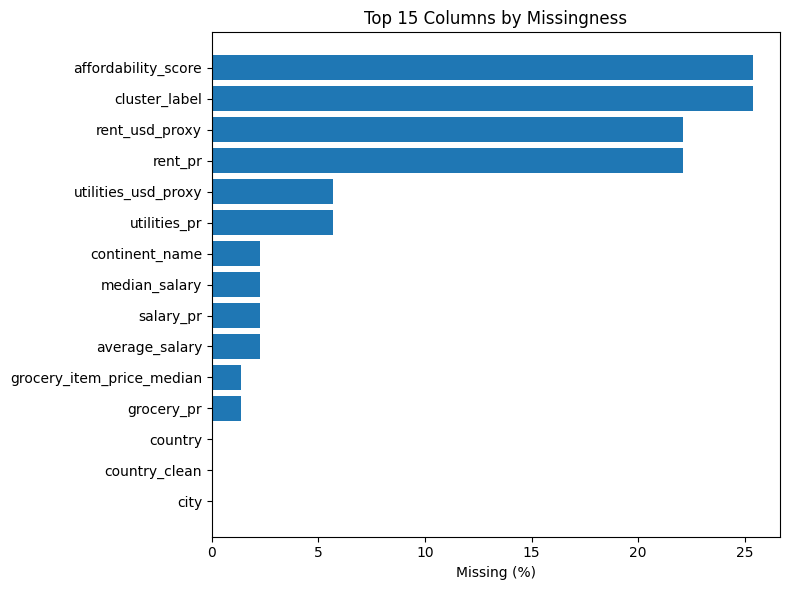

In [ ]:
miss_chart = schema_df[['column','missing_pct']].sort_values('missing_pct', ascending=False).head(15)
plt.figure(figsize=(8,6))
plt.barh(miss_chart['column'], miss_chart['missing_pct'])
plt.xlabel("Missing (%)")
plt.title("Top 15 Columns by Missingness")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd, numpy as np, os


PATH = "final project assigment csv.csv"
df = pd.read_csv(PATH)


In [ ]:
import os, numpy as np, pandas as pd

OUT_DIR = "step2_reports"
os.makedirs(OUT_DIR, exist_ok=True)

expected = [
    "city","country","continent_name",
    "median_salary","average_salary",
    "rent_usd_proxy","utilities_usd_proxy","grocery_item_price_median",
    "affordability_score","cluster_label"
]
missing_cols = [c for c in expected if c not in df.columns]
print("Missing expected cols:", missing_cols)


Missing expected cols: []


In [ ]:
num_cols = [
    "median_salary","average_salary",
    "rent_usd_proxy","utilities_usd_proxy","grocery_item_price_median",
    "affordability_score"
]

desc = df[num_cols].describe(percentiles=[.1,.25,.5,.75,.9]).T
desc["missing"] = df[num_cols].isna().sum().values
desc["missing_pct"] = (desc["missing"] / len(df) * 100).round(2)
desc["iqr"] = desc["75%"] - desc["25%"]
desc = desc[["count","missing","missing_pct","mean","std","min","10%","25%","50%","75%","90%","max","iqr"]]
desc.to_csv(f"{OUT_DIR}/step2_descriptive_stats.csv", index=True)
desc.head(10)


,count,missing,missing_pct,mean,std,min,10%,25%,50%,75%,90%,max,iqr
median_salary,4843.0,113,2.28,3443.440121,2536.353730,0.261335,417.180000,1148.840000,3158.67000,6311.030000,6966.000000,9836.070000,5162.190000
average_salary,4843.0,113,2.28,3903.102619,2896.687896,0.285524,470.350000,1308.810000,3453.12000,7352.940000,7925.000000,11292.900000,6044.130000
rent_usd_proxy,3861.0,1095,22.09,842.839503,767.210365,19.660000,149.425000,295.355000,623.46500,1183.380000,1828.995000,15238.505000,888.025000
utilities_usd_proxy,4675.0,281,5.67,88.526835,41.657132,9.830000,43.956000,64.060000,84.76000,106.670000,129.484000,597.120000,42.610000
grocery_item_price_median,4887.0,69,1.39,2.253713,1.347670,0.140000,1.003000,1.310000,2.01000,2.975000,3.845000,30.000000,1.665000
affordability_score,3698.0,1258,25.38,50.206544,7.074532,14.705609,41.658139,46.677469,50.41691,54.399157,58.677996,76.420742,7.721688


In [ ]:
df = df.copy()


salary = df["median_salary"].replace({0: np.nan})

df["rent_to_salary_pct"]     = (df["rent_usd_proxy"]      / salary) * 100
df["grocery_to_salary_pct"]  = (df["grocery_item_price_median"] / salary) * 100  # grocery is a proxy index; use as *relative* burden
df["utilities_to_salary_pct"]= (df["utilities_usd_proxy"] / salary) * 100

df["essential_cost_usd"] = df["rent_usd_proxy"] + df["utilities_usd_proxy"] + df["grocery_item_price_median"]
df["essential_to_salary_pct"] = (df["essential_cost_usd"] / salary) * 100


df.to_csv(f"{OUT_DIR}/step2_enriched_city_level.csv", index=False)


burden_cols = ["rent_to_salary_pct","grocery_to_salary_pct","utilities_to_salary_pct","essential_to_salary_pct"]
burden_desc = df[burden_cols].describe(percentiles=[.1,.25,.5,.75,.9]).T
burden_desc["missing"] = df[burden_cols].isna().sum().values
burden_desc["missing_pct"] = (burden_desc["missing"] / len(df) * 100).round(2)
burden_desc.to_csv(f"{OUT_DIR}/step2_burden_descriptive_stats.csv")
burden_desc


,count,mean,std,min,10%,25%,50%,75%,90%,max,missing,missing_pct
rent_to_salary_pct,3763.0,70.914480,2190.246067,3.090425,11.804495,16.508757,23.461856,34.075833,52.824638,134304.607603,1193,24.07
grocery_to_salary_pct,4774.0,0.754586,18.600753,0.003969,0.041493,0.052110,0.069769,0.114880,0.258164,591.195119,182,3.67
utilities_to_salary_pct,4566.0,42.832817,1196.813902,0.457036,1.273131,1.701808,3.039025,5.653581,11.660336,40423.205399,390,7.87
essential_to_salary_pct,3698.0,89.420526,2883.969632,5.100517,14.479973,19.320705,26.887162,39.963006,62.738802,175299.875593,1258,25.38


In [ ]:
def export_rank(table, sort_col, k=20, asc=False, name=""):
    top = table.sort_values(sort_col, ascending=asc).head(k)
    bot = table.sort_values(sort_col, ascending=not asc).head(k)
    top.to_csv(f"{OUT_DIR}/rank_top_{k}_{name}_{'asc' if asc else 'desc'}.csv", index=False)
    bot.to_csv(f"{OUT_DIR}/rank_bottom_{k}_{name}_{'asc' if asc else 'desc'}.csv", index=False)
    return top, bot

rank_cols = [
    "affordability_score",
    "rent_to_salary_pct","grocery_to_salary_pct","utilities_to_salary_pct",
    "essential_to_salary_pct"
]
rank_base = df[["city","country","continent_name"] + rank_cols].copy()

top_aff, bot_aff = export_rank(rank_base.dropna(subset=["affordability_score"]),
                               "affordability_score", k=25, asc=False, name="affordability_score")

top_rent, bot_rent = export_rank(rank_base.dropna(subset=["rent_to_salary_pct"]),
                                 "rent_to_salary_pct", k=25, asc=True, name="rent_to_salary_pct")

top_ess, bot_ess = export_rank(rank_base.dropna(subset=["essential_to_salary_pct"]),
                               "essential_to_salary_pct", k=25, asc=True, name="essential_to_salary_pct")

top_aff.head(10), top_rent.head(10), top_ess.head(10)


(               city         country    continent_name  affordability_score  \
 4475        Emporia   United States  Northern America            76.420742   
 4887     Treherbert  United Kingdom            Europe            73.987465   
 115          Guilin           China              Asia            73.008063   
 240          Fushun           China              Asia            72.062303   
 145        Baojishi           China              Asia            71.795964   
 40          Nanyang           China              Asia            71.761603   
 138         Taiyuan           China              Asia            71.454367   
 85          Maoming           China              Asia            70.977244   
 1472  Hafr al Batin    Saudi Arabia              Asia            69.663800   
 4072     Pine Bluff   United States  Northern America            69.565234   
 
       rent_to_salary_pct  grocery_to_salary_pct  utilities_to_salary_pct  \
 4475            4.809073               0.028711    

In [ ]:
def rollup(group_cols):
    g = (
        df.groupby(group_cols, dropna=False)
          .agg(
              cities=("city","nunique"),
              med_salary=("median_salary","median"),
              mean_salary=("median_salary","mean"),
              med_rent=("rent_usd_proxy","median"),
              med_grocery=("grocery_item_price_median","median"),
              med_util=("utilities_usd_proxy","median"),
              med_aff=("affordability_score","median"),
              p90_aff=("affordability_score", lambda s: np.nanpercentile(s.dropna(), 90) if s.notna().any() else np.nan),
              med_ess_to_salary=("essential_to_salary_pct","median"),
              unaffordable_share=("essential_to_salary_pct", lambda s: float(np.mean(s>100)) if s.notna().any() else np.nan)
          )
          .reset_index()
          .sort_values("med_aff", ascending=False)
    )
    return g

country_roll = rollup(["country"])
continent_roll = rollup(["continent_name"])

country_roll.to_csv(f"{OUT_DIR}/step2_country_rollup.csv", index=False)
continent_roll.to_csv(f"{OUT_DIR}/step2_continent_rollup.csv", index=False)

country_roll.head(10), continent_roll


(          country  cities  med_salary  mean_salary  med_rent  med_grocery  \
 39          China     104     3684.93      3684.93  353.5150       1.4075   
 166  Saudi Arabia      18     3840.00      3840.00  393.2025       1.6400   
 164    San Marino       3     4450.32      4450.32  522.9225       1.8400   
 210     Venezuela      18     3282.02      3282.02  202.0000       1.7450   
 13     Azerbaijan      11     1558.82      1558.82  144.6100       1.0600   
 144          Oman       7     3932.29      3932.29  338.9575       2.2600   
 129       Morocco      32     1634.24      1634.24  201.2350       1.0125   
 44     Costa Rica       2     4016.06      4016.06  476.5450       2.0400   
 36     Cape Verde       2     1706.29      1706.29  190.2000       1.4475   
 196       Tunisia      22     1088.33      1088.33  152.6950       0.6875   
 
      med_util    med_aff    p90_aff  med_ess_to_salary  unaffordable_share  
 39     73.490  64.058711  68.975839          11.492349       

In [ ]:
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = np.percentile(s, [25,75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return low, high

low_aff, high_aff = iqr_outliers(df["affordability_score"])
_, high_rent_burden = iqr_outliers(df["rent_to_salary_pct"])
_, high_ess_burden  = iqr_outliers(df["essential_to_salary_pct"])

flags = df[["city","country","continent_name","affordability_score","rent_to_salary_pct","essential_to_salary_pct"]].copy()
flags["flag_low_affordability"] = (flags["affordability_score"] < low_aff).astype(int)
flags["flag_high_rent_burden"]  = (flags["rent_to_salary_pct"] > high_rent_burden).astype(int)
flags["flag_high_ess_burden"]   = (flags["essential_to_salary_pct"] > high_ess_burden).astype(int)
flags["flag_unaffordable_100pct+"] = (flags["essential_to_salary_pct"] > 100).astype(int)

flags.to_csv(f"{OUT_DIR}/step2_outlier_flags.csv", index=False)
flags.sort_values(["flag_unaffordable_100pct+","flag_high_ess_burden","flag_low_affordability"], ascending=False).head(25)


,city,country,continent_name,affordability_score,rent_to_salary_pct,essential_to_salary_pct,flag_low_affordability,flag_high_rent_burden,flag_high_ess_burden,flag_unaffordable_100pct+
15,Lagos,Nigeria,Africa,21.279146,469.153521,487.107862,1,1,1,1
18,Moscow,Russia,Europe,28.221594,118.210987,133.356398,1,1,1,1
22,Istanbul,Turkey,Asia,31.743820,237.062180,264.756002,1,1,1,1
23,Buenos Aires,Argentina,South America,35.003370,342.999637,425.530468,1,1,1,1
43,Luanda,Angola,Africa,30.654258,99.688808,173.684025,1,1,1,1
81,Khartoum,Sudan,Africa,30.478530,720.063600,784.277474,1,1,1,1
104,Rangoon,Myanmar,Asia,34.281793,262.628031,321.855029,1,1,1,1
167,Sanaa,Yemen,Asia,34.508235,201.777153,250.136386,1,1,1,1
191,Santo Domingo,Dominican Republic,Caribbean,22.439750,241.860830,274.771865,1,1,1,1
192,Ibadan,Nigeria,Africa,33.614356,196.351161,205.319995,1,1,1,1


In [ ]:
corr_cols = [
    "median_salary",
    "rent_usd_proxy","utilities_usd_proxy","grocery_item_price_median",
    "affordability_score",
    "rent_to_salary_pct","grocery_to_salary_pct","utilities_to_salary_pct","essential_to_salary_pct"
]

num = df[corr_cols].copy()
pearson = num.corr(method="pearson")
spearman = num.corr(method="spearman")

pearson.to_csv(f"{OUT_DIR}/step2_correlation_pearson.csv")
spearman.to_csv(f"{OUT_DIR}/step2_correlation_spearman.csv")

pearson.round(3)


,median_salary,rent_usd_proxy,utilities_usd_proxy,grocery_item_price_median,affordability_score,rent_to_salary_pct,grocery_to_salary_pct,utilities_to_salary_pct,essential_to_salary_pct
median_salary,1.000,0.701,0.401,0.662,0.345,-0.029,-0.051,-0.046,-0.030
rent_usd_proxy,0.701,1.000,0.355,0.653,-0.142,-0.006,-0.017,-0.016,-0.009
utilities_usd_proxy,0.401,0.355,1.000,0.444,-0.196,0.006,0.010,0.014,0.006
grocery_item_price_median,0.662,0.653,0.444,1.000,-0.073,-0.013,-0.013,-0.022,-0.014
affordability_score,0.345,-0.142,-0.196,-0.073,1.000,-0.055,-0.052,-0.049,-0.054
rent_to_salary_pct,-0.029,-0.006,0.006,-0.013,-0.055,1.000,1.000,0.999,1.000
grocery_to_salary_pct,-0.051,-0.017,0.010,-0.013,-0.052,1.000,1.000,1.000,1.000
utilities_to_salary_pct,-0.046,-0.016,0.014,-0.022,-0.049,0.999,1.000,1.000,0.999
essential_to_salary_pct,-0.030,-0.009,0.006,-0.014,-0.054,1.000,1.000,0.999,1.000


In [ ]:
cluster_prof = (
    df.groupby("cluster_label", dropna=False)
      .agg(
          cities=("city","nunique"),
          med_salary=("median_salary","median"),
          med_rent=("rent_usd_proxy","median"),
          med_grocery=("grocery_item_price_median","median"),
          med_util=("utilities_usd_proxy","median"),
          med_aff=("affordability_score","median"),
          med_rent_to_salary=("rent_to_salary_pct","median"),
          med_ess_to_salary=("essential_to_salary_pct","median")
      ).reset_index()
      .sort_values("med_aff", ascending=False)
)
cluster_prof.to_csv(f"{OUT_DIR}/step2_cluster_profiles.csv", index=False)
cluster_prof


,cluster_label,cities,med_salary,med_rent,med_grocery,med_util,med_aff,med_rent_to_salary,med_ess_to_salary
1,High Salary–High Cost,819,6966.00,1249.055,3.0175,92.8050,53.977821,18.716090,20.277472
0,High Cost–Low Salary,1533,1148.84,265.280,1.2600,61.8800,50.430772,25.290855,31.399877
2,High Salary–Moderate Cost,367,6966.00,2300.000,3.9125,110.1400,49.135859,32.970858,34.721648
3,Low Salary–Low Cost,962,3467.23,711.280,2.2100,106.7925,47.977471,22.851062,26.419153
4,NaN,1255,3158.67,575.160,2.0000,84.3000,NaN,17.358594,NaN


In [ ]:
corr_targets = [
    "median_salary","rent_usd_proxy","utilities_usd_proxy","grocery_item_price_median","affordability_score"
]
corr_matrix = df[corr_targets].corr(method="pearson").round(3)
corr_matrix.to_csv("step3_affordability_correlations.csv")
corr_matrix


,median_salary,rent_usd_proxy,utilities_usd_proxy,grocery_item_price_median,affordability_score
median_salary,1.000,0.701,0.401,0.662,0.345
rent_usd_proxy,0.701,1.000,0.355,0.653,-0.142
utilities_usd_proxy,0.401,0.355,1.000,0.444,-0.196
grocery_item_price_median,0.662,0.653,0.444,1.000,-0.073
affordability_score,0.345,-0.142,-0.196,-0.073,1.000


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

model_df = df.dropna(subset=["affordability_score","median_salary","rent_usd_proxy","grocery_item_price_median","utilities_usd_proxy"]).copy()

X = model_df[["median_salary","rent_usd_proxy","grocery_item_price_median","utilities_usd_proxy"]]
y = model_df["affordability_score"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

coefs = pd.DataFrame({
    "variable": X.columns,
    "standardized_coef": model.coef_.round(3)
}).sort_values("standardized_coef", key=abs, ascending=False)

coefs.to_csv("step3_standardized_coefficients.csv", index=False)
coefs


,variable,standardized_coef
0,median_salary,9.433
2,grocery_item_price_median,-4.289
1,rent_usd_proxy,-4.107
3,utilities_usd_proxy,-1.868


In [ ]:
r2 = model.score(X_scaled, y)
print(f"R²: {r2:.3f} — this means {r2*100:.1f}% of the variation in affordability score is explained by salary, rent, groceries, and utilities.")


R²: 0.639 — this means 63.9% of the variation in affordability score is explained by salary, rent, groceries, and utilities.


In [ ]:
model_df["pred_affordability"] = model.predict(X_scaled)
model_df["residual"] = model_df["affordability_score"] - model_df["pred_affordability"]


overachievers = model_df.sort_values("residual", ascending=False)[["city","country","affordability_score","pred_affordability","residual"]].head(20)

underachievers = model_df.sort_values("residual", ascending=True)[["city","country","affordability_score","pred_affordability","residual"]].head(20)

overachievers.to_csv("step3_overachievers.csv", index=False)
underachievers.to_csv("step3_underachievers.csv", index=False)


In [ ]:
coefs_abs = coefs.copy()
coefs_abs["abs_coef"] = coefs_abs["standardized_coef"].abs()
coefs_abs["importance_pct"] = (coefs_abs["abs_coef"] / coefs_abs["abs_coef"].sum() * 100).round(1)
coefs_abs.sort_values("importance_pct", ascending=False).to_csv("step3_driver_importance.csv", index=False)
coefs_abs.sort_values("importance_pct", ascending=False)


,variable,standardized_coef,abs_coef,importance_pct
0,median_salary,9.433,9.433,47.9
2,grocery_item_price_median,-4.289,4.289,21.8
1,rent_usd_proxy,-4.107,4.107,20.9
3,utilities_usd_proxy,-1.868,1.868,9.5


In [ ]:

cluster_profiles = (
    df.groupby("cluster_label", dropna=False)
      .agg(
          cities=("city","nunique"),
          countries=("country","nunique"),
          med_salary=("median_salary","median"),
          med_rent=("rent_usd_proxy","median"),
          med_grocery=("grocery_item_price_median","median"),
          med_util=("utilities_usd_proxy","median"),
          med_aff_score=("affordability_score","median"),
          med_rent_burden=("rent_to_salary_pct","median"),
          med_ess_burden=("essential_to_salary_pct","median")
      )
      .reset_index()
      .sort_values("med_aff_score", ascending=False)
)

cluster_profiles.to_csv("step4_cluster_profiles.csv", index=False)
cluster_profiles


,cluster_label,cities,countries,med_salary,med_rent,med_grocery,med_util,med_aff_score,med_rent_burden,med_ess_burden
1,High Salary–High Cost,819,19,6966.00,1249.055,3.0175,92.8050,53.977821,18.716090,20.277472
0,High Cost–Low Salary,1533,127,1148.84,265.280,1.2600,61.8800,50.430772,25.290855,31.399877
2,High Salary–Moderate Cost,367,20,6966.00,2300.000,3.9125,110.1400,49.135859,32.970858,34.721648
3,Low Salary–Low Cost,962,104,3467.23,711.280,2.2100,106.7925,47.977471,22.851062,26.419153
4,NaN,1255,156,3158.67,575.160,2.0000,84.3000,NaN,17.358594,NaN


In [ ]:
continent_profiles = (
    df.groupby("continent_name", dropna=False)
      .agg(
          cities=("city","nunique"),
          countries=("country","nunique"),
          med_salary=("median_salary","median"),
          med_rent=("rent_usd_proxy","median"),
          med_grocery=("grocery_item_price_median","median"),
          med_util=("utilities_usd_proxy","median"),
          med_aff_score=("affordability_score","median"),
          med_rent_burden=("rent_to_salary_pct","median"),
          med_ess_burden=("essential_to_salary_pct","median")
      )
      .reset_index()
      .sort_values("med_aff_score", ascending=False)
)

continent_profiles.to_csv("step4_continent_profiles.csv", index=False)
continent_profiles


,continent_name,cities,countries,med_salary,med_rent,med_grocery,med_util,med_aff_score,med_rent_burden,med_ess_burden
8,South America,324,13,1490.040,271.8225,1.310,60.5800,53.933223,19.857738,24.325397
6,Northern America,1194,4,6966.000,1563.8250,3.465,97.5000,52.390542,22.968705,24.567471
3,Central America,127,8,1681.970,358.7950,1.595,64.4600,50.341945,24.527786,28.277826
4,Europe,1751,45,3467.230,658.5950,2.005,94.8400,50.113917,22.363353,26.026416
0,Africa,324,49,645.210,233.5000,1.130,50.3400,49.521722,33.132566,39.479271
1,Asia,953,45,728.780,233.2450,1.255,59.2100,48.888360,28.263257,38.122389
7,Oceania,107,13,4306.450,1106.2550,2.890,103.5475,45.826844,26.826853,29.323341
2,Caribbean,54,12,674.555,549.1250,2.345,78.0000,34.660418,63.060930,72.238076
5,North America,1,1,3541.000,1639.6250,4.620,120.0000,32.411843,46.304010,49.823355
9,NaN,113,25,NaN,646.7525,2.020,101.7600,NaN,NaN,NaN


In [ ]:

df["aff_qtile"] = pd.qcut(df["affordability_score"], 4, labels=["Q1_Lowest","Q2_Low","Q3_High","Q4_Highest"])

quartile_profiles = (
    df.groupby("aff_qtile", dropna=False)
      .agg(
          cities=("city","nunique"),
          countries=("country","nunique"),
          med_salary=("median_salary","median"),
          med_rent=("rent_usd_proxy","median"),
          med_grocery=("grocery_item_price_median","median"),
          med_util=("utilities_usd_proxy","median"),
          med_aff_score=("affordability_score","median"),
          med_rent_burden=("rent_to_salary_pct","median"),
          med_ess_burden=("essential_to_salary_pct","median")
      )
      .reset_index()
      .sort_values("med_aff_score", ascending=False)
)

quartile_profiles.to_csv("step4_quartile_profiles.csv", index=False)
quartile_profiles


/tmp/ipython-input-46540001.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("aff_qtile", dropna=False)


,aff_qtile,cities,countries,med_salary,med_rent,med_grocery,med_util,med_aff_score,med_rent_burden,med_ess_burden
3,Q4_Highest,924,55,3731.50,468.9150,1.7900,75.67,57.713994,13.278783,15.781136
2,Q3_High,921,76,3731.50,711.5250,2.2075,84.51,52.208821,20.815389,24.010482
1,Q2_Low,923,89,3158.67,664.4925,2.1100,88.97,48.728300,27.915861,31.676739
0,Q1_Lowest,921,164,1246.44,634.5250,1.8700,96.40,42.911316,41.717090,48.741271
4,NaN,1255,156,3158.67,575.1600,2.0000,84.30,NaN,17.358594,NaN


In [1]:

top_per_cluster = (
    df.sort_values("affordability_score", ascending=False)
      .groupby("cluster_label")
      .head(10)
      [["city","country","affordability_score","median_salary","rent_to_salary_pct","essential_to_salary_pct"]]
)
top_per_cluster.to_csv("step4_top10_per_cluster.csv", index=False)


bottom_per_cluster = (
    df.sort_values("affordability_score", ascending=True)
      .groupby("cluster_label")
      .head(10)
      [["city","country","affordability_score","median_salary","rent_to_salary_pct","essential_to_salary_pct"]]
)
bottom_per_cluster.to_csv("step4_bottom10_per_cluster.csv", index=False)


NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (8,6)
})


/tmp/ipython-input-2925221608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


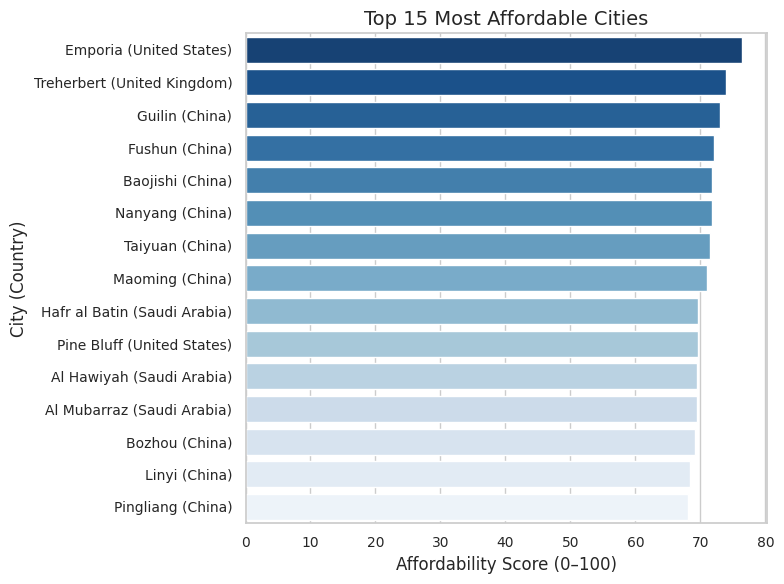

In [ ]:
top15_aff = df.sort_values("affordability_score", ascending=False).head(15)

plt.figure()
sns.barplot(
    data=top15_aff,
    y=top15_aff["city"] + " (" + top15_aff["country"] + ")",
    x="affordability_score",
    palette="Blues_r"
)
plt.xlabel("Affordability Score (0–100)")
plt.ylabel("City (Country)")
plt.title("Top 15 Most Affordable Cities")
plt.tight_layout()
plt.savefig("step5_top15_affordable.png", dpi=300)


/tmp/ipython-input-3907536680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


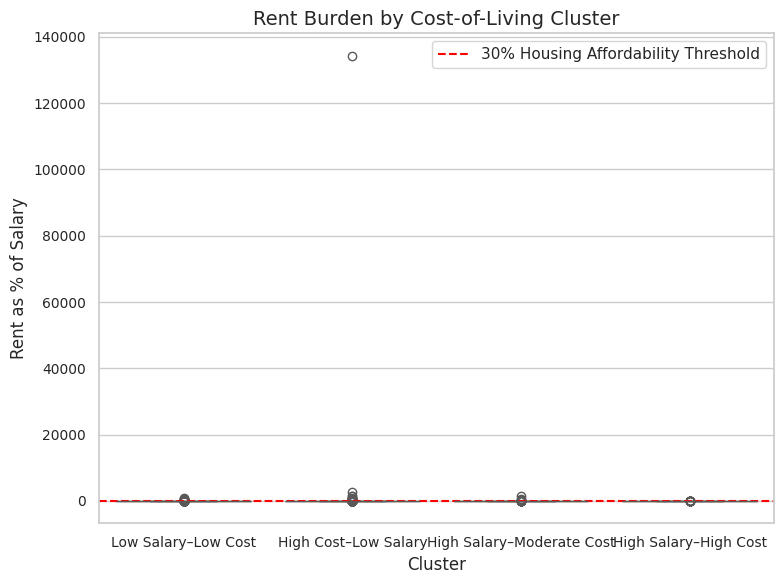

In [ ]:
plt.figure()
sns.boxplot(
    data=df,
    x="cluster_label",
    y="rent_to_salary_pct",
    palette="Set2"
)
plt.axhline(30, color="red", linestyle="--", label="30% Housing Affordability Threshold")
plt.ylabel("Rent as % of Salary")
plt.xlabel("Cluster")
plt.title("Rent Burden by Cost-of-Living Cluster")
plt.legend()
plt.tight_layout()
plt.savefig("step5_rent_burden_cluster.png", dpi=300)


/tmp/ipython-input-4155028910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


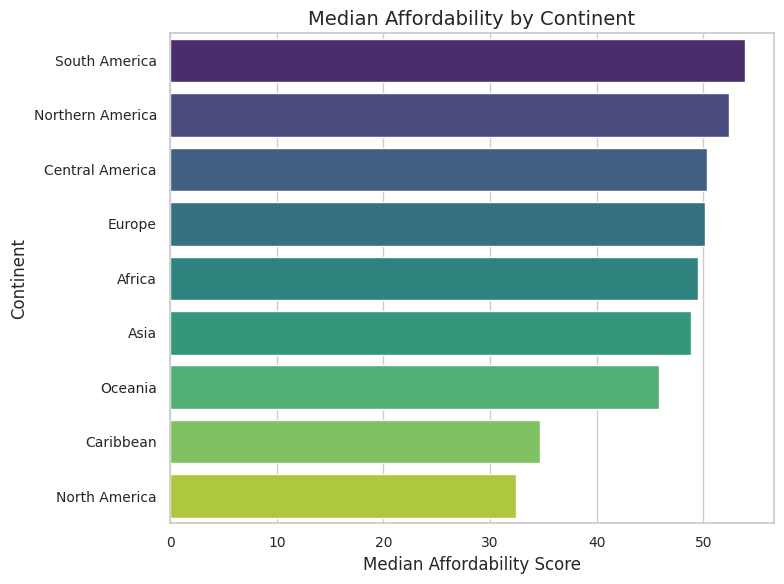

In [ ]:
continent_aff = df.groupby("continent_name", dropna=False)["affordability_score"].median().reset_index()

plt.figure()
sns.barplot(
    data=continent_aff.sort_values("affordability_score", ascending=False),
    x="affordability_score",
    y="continent_name",
    palette="viridis"
)
plt.xlabel("Median Affordability Score")
plt.ylabel("Continent")
plt.title("Median Affordability by Continent")
plt.tight_layout()
plt.savefig("step5_affordability_continent.png", dpi=300)


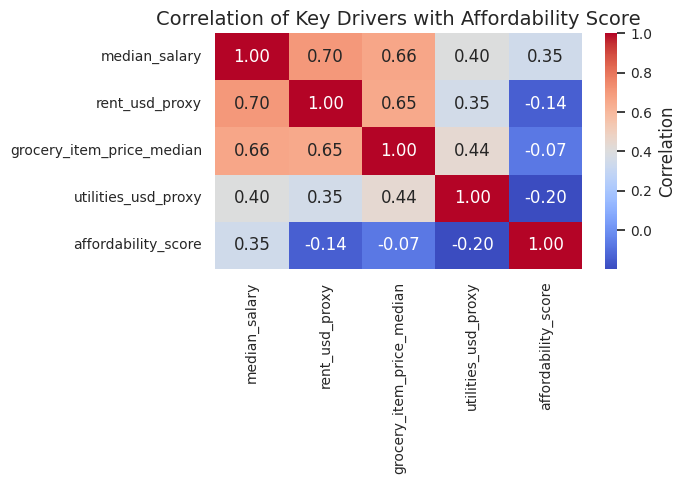

In [ ]:
corr_cols = ["median_salary","rent_usd_proxy","grocery_item_price_median","utilities_usd_proxy","affordability_score"]
corr = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.title("Correlation of Key Drivers with Affordability Score")
plt.tight_layout()
plt.savefig("step5_correlation_heatmap.png", dpi=300)


In [ ]:
if "pred_affordability" in df.columns:
    plt.figure()
    sns.scatterplot(
        data=df,
        x="pred_affordability",
        y="affordability_score",
        hue="cluster_label",
        palette="Set1"
    )
    plt.plot([0,100],[0,100], color="gray", linestyle="--")
    plt.xlabel("Predicted Affordability Score")
    plt.ylabel("Actual Affordability Score")
    plt.title("Overachievers vs Underachievers")
    plt.tight_layout()
    plt.savefig("step5_over_under_scatter.png", dpi=300)


In [ ]:
import pandas as pd
df = pd.read_csv("final project assigment csv.csv")

In [ ]:
import numpy as np, os
from sklearn.model_selection import train_test_split

OUT_DIR = "step3_tree"
os.makedirs(OUT_DIR, exist_ok=True)

features = ["median_salary","rent_usd_proxy","grocery_item_price_median","utilities_usd_proxy"]
target = "affordability_score"

model_df = df.dropna(subset=features+[target]).copy()
X = model_df[features].values
y = model_df[target].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, model_df.index, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd, numpy as np, json

param_grid = {
    "max_depth": [3,4,5,6,8,10,None],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,5,10]
}

dt = DecisionTreeRegressor(random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(dt, param_grid, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

cv_results = pd.DataFrame(gs.cv_results_)
cv_results.to_csv(f"{OUT_DIR}/dt_cv_results.csv", index=False)

best_dt = gs.best_estimator_
with open(f"{OUT_DIR}/dt_best_params.json","w") as f:
    json.dump(gs.best_params_, f, indent=2)
gs.best_params_


{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [ ]:
from math import sqrt

y_pred_train = best_dt.predict(X_train)
y_pred_test  = best_dt.predict(X_test)

metrics = {
    "train_R2": r2_score(y_train, y_pred_train),
    "test_R2": r2_score(y_test, y_pred_test),
    "train_RMSE": sqrt(mean_squared_error(y_train, y_pred_train)),
    "test_RMSE": sqrt(mean_squared_error(y_test, y_pred_test)),
}
metrics


{'train_R2': 0.9939244945427088,
 'test_R2': 0.9350689269964665,
 'train_RMSE': 0.5490572257799922,
 'test_RMSE': 1.8290684938745878}

In [ ]:
with open(f"{OUT_DIR}/dt_metrics.txt","w") as f:
    for k,v in metrics.items():
        f.write(f"{k}: {v:.4f}\n")

pred_df = model_df.loc[idx_test, ["city","country"]].copy()
pred_df["actual_affordability"] = y_test
pred_df["pred_affordability_dt"] = y_pred_test
pred_df["residual_dt"] = pred_df["actual_affordability"] - pred_df["pred_affordability_dt"]
pred_df.sort_values("residual_dt", ascending=False).head(20).to_csv(f"{OUT_DIR}/dt_overachievers.csv", index=False)
pred_df.sort_values("residual_dt", ascending=True).head(20).to_csv(f"{OUT_DIR}/dt_underachievers.csv", index=False)
pred_df.to_csv(f"{OUT_DIR}/dt_predictions_test.csv", index=False)


In [ ]:
fi = pd.DataFrame({
    "feature": features,
    "tree_importance": best_dt.feature_importances_
}).sort_values("tree_importance", ascending=False)
fi["tree_importance_pct"] = (fi["tree_importance"] / fi["tree_importance"].sum() * 100).round(1)
fi.to_csv(f"{OUT_DIR}/dt_feature_importance.csv", index=False)
fi


,feature,tree_importance,tree_importance_pct
0,median_salary,0.449776,45.0
1,rent_usd_proxy,0.403763,40.4
2,grocery_item_price_median,0.127729,12.8
3,utilities_usd_proxy,0.018732,1.9


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_dt, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": features,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std
}).sort_values("perm_importance_mean", ascending=False)
perm_df.to_csv(f"{OUT_DIR}/dt_permutation_importance.csv", index=False)
perm_df


,feature,perm_importance_mean,perm_importance_std
0,median_salary,5.011748,0.223266
1,rent_usd_proxy,1.893535,0.103543
2,grocery_item_price_median,0.663945,0.035738
3,utilities_usd_proxy,0.028713,0.003404


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_metrics = {
    "test_R2": r2_score(y_test, y_pred_rf),
    "test_RMSE": sqrt(mean_squared_error(y_test, y_pred_rf)),
}
rf_metrics


{'test_R2': 0.9753141499710914, 'test_RMSE': 1.1277886569169528}

In [ ]:
rf_fi = pd.DataFrame({"feature": features, "rf_importance": rf.feature_importances_}).sort_values("rf_importance", ascending=False)
rf_fi["rf_importance_pct"] = (rf_fi["rf_importance"] / rf_fi["rf_importance"].sum() * 100).round(1)
rf_fi.to_csv(f"{OUT_DIR}/rf_feature_importance.csv", index=False)

perm_rf = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_rf_df = pd.DataFrame({
    "feature": features,
    "perm_importance_mean": perm_rf.importances_mean,
    "perm_importance_std": perm_rf.importances_std
}).sort_values("perm_importance_mean", ascending=False)
perm_rf_df.to_csv(f"{OUT_DIR}/rf_permutation_importance.csv", index=False)
perm_rf_df


,feature,perm_importance_mean,perm_importance_std
0,median_salary,4.748000,0.205053
1,rent_usd_proxy,1.789003,0.071904
2,grocery_item_price_median,0.517372,0.016120
3,utilities_usd_proxy,0.031415,0.001509


In [ ]:
with open(f"{OUT_DIR}/rf_metrics.txt","w") as f:
    for k,v in rf_metrics.items():
        f.write(f"{k}: {v:.4f}\n")


In [2]:
train_R2 = 0.9939244945427088
test_R2 = 0.9350689269964665
train_RMSE = 0.5490572257799922
test_RMSE = 1.8290684938745878
